In [ ]:
import torch.nn as nn

from black_scholes.pinn.bs_pinn import BlackScholesPINN
from utility.model import EarlyStopping
from config.bs_1d import *

In [4]:
# seeds = [40, 41, 42, 43, 44]
# seeds = range(30)
seeds = range(3)
for seed in seeds:
    print("Training with seed:", seed)
    pinn = BlackScholesPINN(model_config, seed=seed)
    pinn.set_params(K, r, sigma, T, S_min, S_max)

    early_stopping = EarlyStopping(patience=500, min_delta=1e-7)
    pinn.train(batch_size=10000, epochs=30000, early_stopping=early_stopping, anneal_freq=50000, alpha=0.9)
    pinn.save(f'../models/bs_pinn_1d/big/{seed}.pth')

Training with seed: 0
Iter      0 | Train: 2.6499e-01 | Val: 9.9286e-01 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter    500 | Train: 2.8857e-03 | Val: 1.1492e-02 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   1000 | Train: 1.1209e-03 | Val: 4.3217e-03 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   1500 | Train: 7.3320e-04 | Val: 2.9512e-03 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   2000 | Train: 2.4429e-04 | Val: 9.7826e-04 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   2500 | Train: 1.3044e-04 | Val: 4.8931e-04 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   3000 | Train: 8.7282e-05 | Val: 3.4105e-04 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   3500 | Train: 6.5360e-05 | Val: 2.5590e-04 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   4000 | Train: 5.090

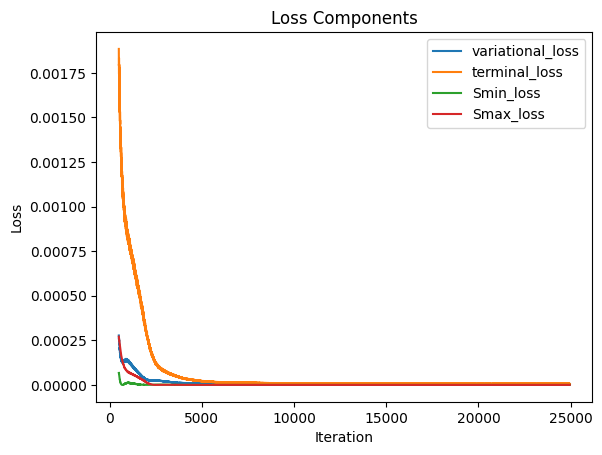

In [5]:
pinn.plot_losses(start_epoch=500, detailed=True)